1. Contexte du projet

Le secteur automobile est aujourd’hui fortement concerné par les enjeux environnementaux, notamment la réduction des émissions de gaz à effet de serre. Parmi ces émissions, le dioxyde de carbone (CO₂) est un indicateur majeur de la pollution liée aux véhicules.
Dans ce contexte, il devient essentiel de :
1.1. comprendre les facteurs techniques qui influencent les émissions de CO₂,
1.2.identifier les véhicules les plus polluants,
1.3.développer des modèles capables de prédire les émissions avant même la mise en circulation d’un véhicule.

L’objectif global est donc de fournir un outil d’aide à la décision permettant d’anticiper l’impact environnemental de nouveaux modèles automobiles.

2. Problematique metier

Quelles caractéristiques techniques d’un véhicule influencent ses émissions de CO₂, et peut-on les prédire à partir de ces caractéristiques ?

3. Perimetre du projet

Le projet s’appuie sur des jeux de données contenant :

- les caractéristiques techniques des véhicules (ex : masse, puissance, carburant, cylindrée…)
- les consommations de carburant (urbain, extra-urbain, mixte)
- les émissions de CO₂
- d’autres polluants atmosphériques

Les données proviennent notamment :

- des véhicules commercialisés en France en 2013 (data.gouv)
- d’une base européenne plus large (EEA) contenant plusieurs années de véhicules


In [1]:
import pandas as pd
df = pd.read_csv("../src/mars-2014-complete.csv",encoding="latin1", sep=";", low_memory=False)
df.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,...,1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,...,1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,...,1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN


In [2]:
# la taille de dataset
df.shape

(55044, 30)

In [34]:
# doublons
df.duplicated().sum()
df[df.duplicated(keep=False)]

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme
1257,CITROEN,C3,C3,C3 VTI (82ch) BVM5,M10CTRVP0051686,SCHMZ0,ES,non,4,60.0,...,NaN,NaN,NaN,NaN,1050,1050,"""715/2007*630/2012EURO5",NaN,BERLINE,INFERIEURE
1258,CITROEN,C3,C3,C3 VTI (82ch) BVM5,M10CTRVP0051686,SCHMZ0,ES,non,4,60.0,...,NaN,NaN,NaN,NaN,1050,1050,"""715/2007*630/2012EURO5",NaN,BERLINE,INFERIEURE
1458,DACIA,SANDERO,SANDERO,Nouvelle SANDERO Stepway TCe (90ch),M10DACVP000J609,5SDAAC,ES,non,5,66.0,...,NaN,NaN,NaN,NaN,1098,1180,715/2007*630/2012EURO5,mars-14,BERLINE,INFERIEURE
1459,DACIA,SANDERO,SANDERO,Nouvelle SANDERO Stepway TCe (90ch),M10DACVP000J609,5SDAAC,ES,non,5,66.0,...,NaN,NaN,NaN,NaN,1098,1180,715/2007*630/2012EURO5,mars-14,BERLINE,INFERIEURE
1460,DACIA,SANDERO,SANDERO,Nouvelle SANDERO TCe (90ch) eco2,M10DACVP000W622,5SDAA5,ES,non,5,66.0,...,NaN,NaN,NaN,NaN,1037,1150,715/2007*630/2012EURO5,mars-14,BERLINE,INFERIEURE
1461,DACIA,SANDERO,SANDERO,Nouvelle SANDERO TCe (90ch) eco2,M10DACVP000W622,5SDAA5,ES,non,5,66.0,...,NaN,NaN,NaN,NaN,1037,1150,715/2007*630/2012EURO5,mars-14,BERLINE,INFERIEURE
2383,HYUNDAI,IX 35,IX 35,ix35 1.6 GDI (135ch) Blue Drive PACK Evidence ...,M10HMCVP001X448,ELHF5P31M64AZ1,ES,non,8,99.0,...,NaN,NaN,NaN,0.0,1380,1502,715/2007*195/2013EURO5,dÚc-13,TS TERRAINS/CHEMINS,MOY-SUPER
2384,HYUNDAI,IX 35,IX 35,ix35 1.6 GDI (135ch) Blue Drive PACK Evidence ...,M10HMCVP001X448,ELHF5P31M64AZ1,ES,non,8,99.0,...,NaN,NaN,NaN,0.0,1380,1502,715/2007*195/2013EURO5,dÚc-13,TS TERRAINS/CHEMINS,MOY-SUPER
40309,PEUGEOT,107,107,107 3P 1.0e Blue Lion,M10PGTVP0086492,PMCFB4,ES,non,4,50.0,...,NaN,NaN,NaN,NaN,875,925,715/2007*630/2012EURO5,mars-14,BERLINE,ECONOMIQUE
40310,PEUGEOT,107,107,107 3P 1.0e Blue Lion,M10PGTVP0086492,PMCFB4,ES,non,4,50.0,...,NaN,NaN,NaN,NaN,875,925,715/2007*630/2012EURO5,mars-14,BERLINE,ECONOMIQUE


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

In [4]:
# presence des nulls
df.isnull().sum()

lib_mrq                  0
lib_mod_doss             0
lib_mod                  0
dscom                    0
cnit                     0
tvv                      0
cod_cbr                  0
hybride                  0
puiss_admin_98           0
puiss_max                0
typ_boite_nb_rapp        0
conso_urb               43
conso_exurb             43
conso_mixte             34
co2                     34
co_typ_1               158
hc                   45271
nox                    158
hcnox                 9888
ptcl                  2678
masse_ordma_min          0
masse_ordma_max          0
champ_v9                61
date_maj             51797
Carrosserie              0
gamme                    0
Unnamed: 26          55044
Unnamed: 27          55044
Unnamed: 28          55044
Unnamed: 29          55044
dtype: int64

In [5]:
# afficher uniquement celle qui ont la presence des valeurs nulles
df.isnull().sum()[df.isnull().sum() > 0]

conso_urb         43
conso_exurb       43
conso_mixte       34
co2               34
co_typ_1         158
hc             45271
nox              158
hcnox           9888
ptcl            2678
champ_v9          61
date_maj       51797
Unnamed: 26    55044
Unnamed: 27    55044
Unnamed: 28    55044
Unnamed: 29    55044
dtype: int64

In [6]:
# supprimer des variables NaN : unnamed 26-29 
df = df.drop(columns=[
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
])

In [7]:
#verifier des types et convertir en numerique si necessaire
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

In [8]:
# convertir les types en numerique
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'hc',
    'nox',
    'hcnox',
    'ptcl',
    "co_typ_1"
]

for col in colonnes_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
# verifier les types convertis:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          54851 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          6124 non-null   float64
 12  conso_exurb        4545 non-null   float64
 13  conso_mixte        6496 non-null   float64
 14  co2                55010 non-null  float64
 15  co_typ_1           0 non-null      float64
 16  hc                 580 non-null  

In [10]:
# la representation ponderale des marques
df.describe()

,puiss_admin_98,puiss_max,conso_urb,conso_exurb,conso_mixte,co2,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max
count,55044.000000,54851.000000,6124.000000,4545.000000,6496.000000,55010.000000,0.0,580.0,30.0,11.0,18274.0,55044.000000,55044.000000
mean,10.551504,118.848134,9.157087,6.853245,7.823584,201.707035,NaN,0.0,0.0,0.0,0.0,2102.104553,2341.021801
std,5.126021,44.860591,1.726000,1.080916,1.040802,33.976278,NaN,0.0,0.0,0.0,0.0,294.731715,424.067895
min,1.000000,10.000000,0.000000,3.000000,3.000000,13.000000,NaN,0.0,0.0,0.0,0.0,825.000000,825.000000
25%,9.000000,100.000000,8.000000,7.000000,8.000000,193.000000,NaN,0.0,0.0,0.0,0.0,1982.000000,2075.000000
50%,10.000000,120.000000,9.000000,7.000000,8.000000,205.000000,NaN,0.0,0.0,0.0,0.0,2076.000000,2355.000000
75%,10.000000,120.000000,10.000000,7.000000,8.000000,216.000000,NaN,0.0,0.0,0.0,0.0,2246.000000,2709.000000
max,81.000000,585.000000,23.000000,10.000000,17.000000,572.000000,NaN,0.0,0.0,0.0,0.0,2760.000000,3094.000000


In [11]:
# taux de Nan par variable
(df.isnull().sum() / len(df)) * 100

lib_mrq                0.000000
lib_mod_doss           0.000000
lib_mod                0.000000
dscom                  0.000000
cnit                   0.000000
tvv                    0.000000
cod_cbr                0.000000
hybride                0.000000
puiss_admin_98         0.000000
puiss_max              0.350629
typ_boite_nb_rapp      0.000000
conso_urb             88.874355
conso_exurb           91.742969
conso_mixte           88.198532
co2                    0.061769
co_typ_1             100.000000
hc                    98.946298
nox                   99.945498
hcnox                 99.980016
ptcl                  66.801105
masse_ordma_min        0.000000
masse_ordma_max        0.000000
champ_v9               0.110820
date_maj              94.101083
Carrosserie            0.000000
gamme                  0.000000
dtype: float64

In [12]:
desc = df.select_dtypes(include="number").describe().T

print(desc)

                   count         mean         std    min     25%     50%  \
puiss_admin_98   55044.0    10.551504    5.126021    1.0     9.0    10.0   
puiss_max        54851.0   118.848134   44.860591   10.0   100.0   120.0   
conso_urb         6124.0     9.157087    1.726000    0.0     8.0     9.0   
conso_exurb       4545.0     6.853245    1.080916    3.0     7.0     7.0   
conso_mixte       6496.0     7.823584    1.040802    3.0     8.0     8.0   
co2              55010.0   201.707035   33.976278   13.0   193.0   205.0   
co_typ_1             0.0          NaN         NaN    NaN     NaN     NaN   
hc                 580.0     0.000000    0.000000    0.0     0.0     0.0   
nox                 30.0     0.000000    0.000000    0.0     0.0     0.0   
hcnox               11.0     0.000000    0.000000    0.0     0.0     0.0   
ptcl             18274.0     0.000000    0.000000    0.0     0.0     0.0   
masse_ordma_min  55044.0  2102.104553  294.731715  825.0  1982.0  2076.0   
masse_ordma_

count    55044.000000
mean        10.551504
std          5.126021
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         81.000000
Name: puiss_admin_98, dtype: float64


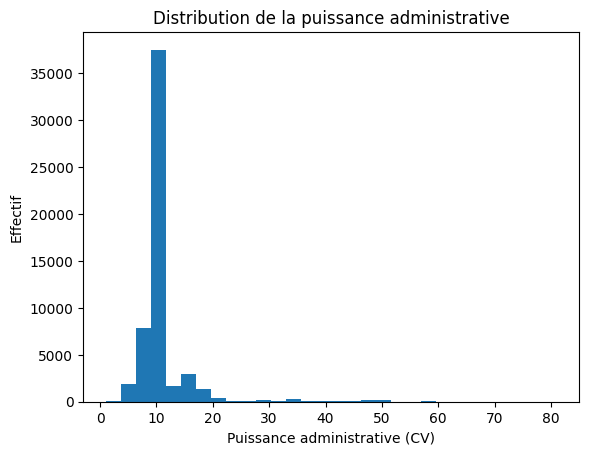

In [13]:
# distribution des variables quantitatives puiss_admin_98
print(df["puiss_admin_98"].describe())


import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["puiss_admin_98"].dropna(), bins=30)
plt.title("Distribution de la puissance administrative")
plt.xlabel("Puissance administrative (CV)")
plt.ylabel("Effectif")
plt.show()


Distribution très concentrée autours de 10(petite valeur), quelques valeurs extrêmes(outliers max 81) → asymétrie à droite

count    54851.000000
mean       118.848134
std         44.860591
min         10.000000
25%        100.000000
50%        120.000000
75%        120.000000
max        585.000000
Name: puiss_max, dtype: float64
puiss_max
120.0    19968
100.0    12636
95.0      4123
80.0      3996
165.0     2470
         ...  
397.0        1
368.0        1
324.0        1
43.0         1
246.0        1
Name: count, Length: 210, dtype: int64


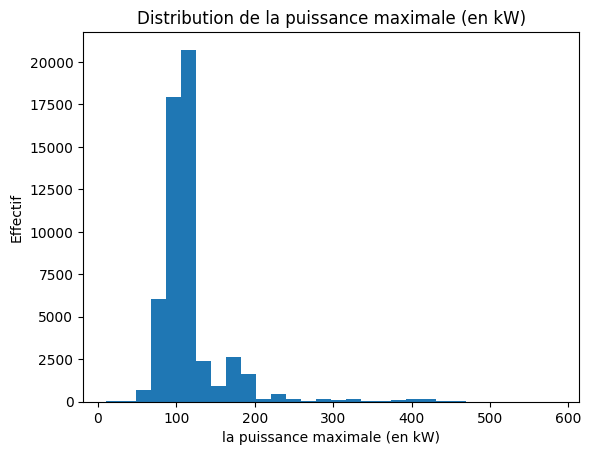

In [14]:
# distribution des variables quantitatives puiss_max
print(df["puiss_max"].describe())
print(df["puiss_max"].value_counts())


import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["puiss_max"].dropna(), bins=30)
plt.title("Distribution de la puissance maximale (en kW)")
plt.xlabel("la puissance maximale (en kW)")
plt.ylabel("Effectif")
plt.show()


In [15]:
df[df["puiss_max"].isna()]
df[["puiss_admin_98", "puiss_max"]].corr()

,puiss_admin_98,puiss_max
puiss_admin_98,1.000000,0.972909
puiss_max,0.972909,1.000000


In [16]:
# detecter des outliers pour variable co2:
Q1 = df["co2"].quantile(0.25)
Q3 = df["co2"].quantile(0.75)
IQR = Q3 - Q1

outliers_co2 = df.loc[
    (df["co2"] < Q1 - 1.5*IQR) | (df["co2"] > Q3 + 1.5*IQR),
    "co2"
]

print(outliers_co2)

2        134.0
3        134.0
4        139.0
5        139.0
6        136.0
         ...  
55034    157.0
55037    139.0
55038    117.0
55039    129.0
55042    139.0
Name: co2, Length: 8135, dtype: float64


<Axes: >

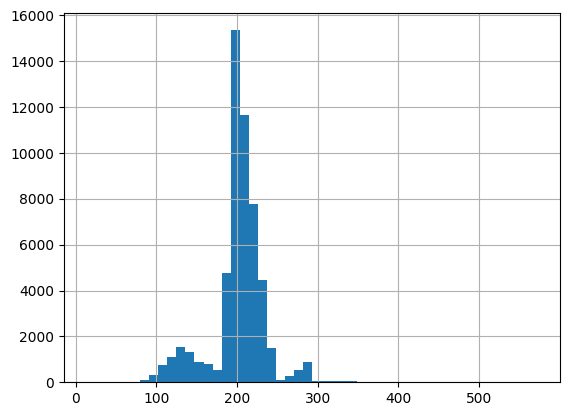

In [17]:
# distribution de variable CO2
df["co2"].hist(bins=50)

In [18]:
df["hc"].describe()
df["hc"].value_counts()
df.corr(numeric_only=True)

,puiss_admin_98,puiss_max,conso_urb,conso_exurb,conso_mixte,co2,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max
puiss_admin_98,1.000000,0.972909,0.584814,0.419560,0.501609,0.463154,NaN,NaN,NaN,NaN,NaN,0.072884,-0.068591
puiss_max,0.972909,1.000000,0.453629,0.316229,0.342918,0.331356,NaN,NaN,NaN,NaN,NaN,0.008063,-0.147207
conso_urb,0.584814,0.453629,1.000000,0.947039,0.990886,0.927157,NaN,NaN,NaN,NaN,NaN,0.376874,0.038781
conso_exurb,0.419560,0.316229,0.947039,1.000000,0.968466,0.967513,NaN,NaN,NaN,NaN,NaN,0.765616,0.726601
conso_mixte,0.501609,0.342918,0.990886,0.968466,1.000000,0.973868,NaN,NaN,NaN,NaN,NaN,0.574197,0.513603
co2,0.463154,0.331356,0.927157,0.967513,0.973868,1.000000,NaN,NaN,NaN,NaN,NaN,0.643665,0.540156
co_typ_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nox,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hcnox,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df["co2"].skew()
#Interprétation du skewness
# ≈ 0 symétrique
# > 0 asymétrie droite
# < 0 asymétrie gauche
# La variable CO₂ présente une légère asymétrie négative (skewness ≈ -0.33), 
# indiquant une distribution globalement équilibrée avec une légère concentration de valeurs élevées.


np.float64(-0.33172862078396875)

In [20]:
# determiner les variables categorielles et les stocker dans cat_data
cat_data = df.select_dtypes(include = 'O')
cat_data.head()

C:\Users\Laura\AppData\Local\Temp\ipykernel_3268\1205252930.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data = df.select_dtypes(include = 'O')


,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,typ_boite_nb_rapp,champ_v9,date_maj,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,M 6,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,M 6,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,M 6,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,M 6,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,M 6,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER


In [21]:
display(cat_data['gamme'].value_counts())

gamme
MOY-INFER         33438
MOY-SUPER         15098
LUXE               3597
SUPERIEURE         1513
INFERIEURE         1073
ECONOMIQUE          269
MOY-INFERIEURE       56
Name: count, dtype: int64

In [22]:
#nombre de categorie de variable gamme
df["gamme"].nunique()


7

In [23]:
import sys
print(sys.executable)

c:\Liora\Projet_CO2\.venv\Scripts\python.exe


cod_cbr
GL        48.000000
EE        49.333333
GH       118.790123
GP/ES    123.608696
EH       139.409396
ES/GP    140.521739
GN/ES    154.875000
GN       172.476190
FE       191.100000
ES/GN    192.156250
GO       202.151853
ES       203.757593
EL              NaN
Name: co2, dtype: float64

           count        mean        std    min    25%    50%     75%    max
cod_cbr                                                                    
EE           9.0   49.333333  22.983690   13.0   27.0   49.0   71.00   72.0
EH         298.0  139.409396  37.404696   79.0  109.0  141.0  156.00  330.0
EL           0.0         NaN        NaN    NaN    NaN    NaN     NaN    NaN
ES        5169.0  203.757593  70.888022   88.0  142.0  184.0  279.00  572.0
ES/GN       32.0  192.156250  79.574315  107.0  107.0  173.0  289.00  289.0
ES/GP       23.0  140.521739  19.683564  119.0  130.5  139.0  145.50  216.0
FE          10.0  191.100000  44.237867  136.0  170.0  170.0  239.25  246.0
GH          81.0  118.790123  14.428891   85.0  110.0  120.0  124.00  169.0
GL           1.0   48.000000        NaN   48.0   48.0   48.0   48.00   48.0
GN          21.0  172.476190  54.898651  115.0  117.0  156.0  238.00  238.0
GN/ES       32.0  154.875000  67.433001   86.0   86.0  134.0  238.00  238.0
GO       493

<Figure size 640x480 with 0 Axes>

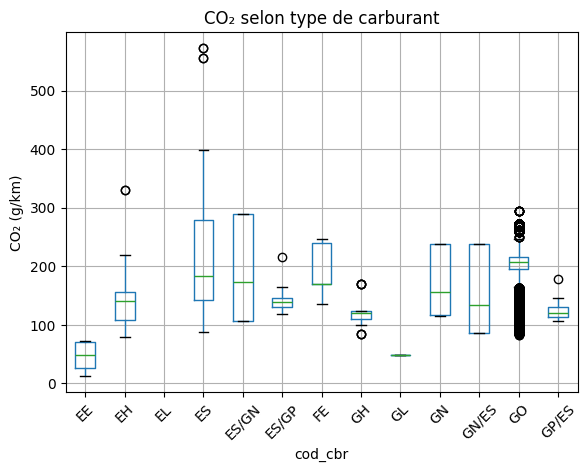

'Statistiques ANOVA: '

,df,sum_sq,mean_sq,F,PR(>F)
C(cod_cbr),12.0,2.300697e+06,191724.764534,172.27954,0.0
Residual,54998.0,6.120563e+07,1112.870191,NaN,NaN


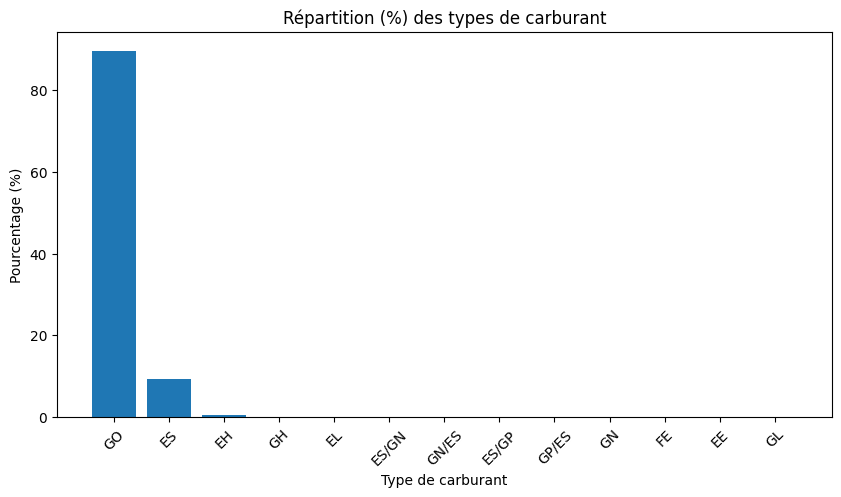

In [35]:
#Le type de carburant influence-t-il les émissions de CO₂ ?
# liste des moyennes par cardinalité de variable carburant
display(df.groupby("cod_cbr")["co2"].mean().sort_values())
# statistiques descriptives de base de chaque type de carburant vs CO2
print(df.groupby("cod_cbr")["co2"].describe())
# distribution des valeurs en boxplot
plt.figure()
df.boxplot(column="co2", by="cod_cbr", rot=45)
plt.title("CO₂ selon type de carburant")
plt.suptitle("")
plt.ylabel("CO₂ (g/km)")
plt.show()

#import statsmodels.api as sm
#from statsmodels.formula.api import ols
#model = ols('co2 ~ C(cod_cbr)', data=df).fit()
#sm.stats.anova_lm(model, typ=2)

import statsmodels.api 
result = statsmodels.formula.api.ols('co2 ~ C(cod_cbr)', data=df).fit()
table = statsmodels.api.stats.anova_lm(result)
display("Statistiques ANOVA: ", table)
import matplotlib.pyplot as plt

counts = df["cod_cbr"].value_counts(normalize=True) * 100

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)

plt.title("Répartition (%) des types de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)

plt.show()


In [25]:
# afficher les modalités de variable dscom :
display(cat_data['tvv'].value_counts())

tvv
F142ABE       4
F142ADE       4
F149CDEL      4
F149CDEB      4
263AXG1B05    4
             ..
BZ73CD        1
BZ8156        1
BZ8256        1
BZ83A4        1
BZ90H6        1
Name: count, Length: 35430, dtype: int64

In [26]:
# afficher les modalités de variable cod_cbr - energie :
display(cat_data['cod_cbr'].value_counts())

cod_cbr
GO       49311
ES        5169
EH         298
GH          81
EL          34
ES/GN       32
GN/ES       32
ES/GP       23
GP/ES       23
GN          21
FE          10
EE           9
GL           1
Name: count, dtype: int64

decodage de type d'energi:
Code	Signification probable	Explication
GO	Gazole (Diesel)	            Le plus courant dans ton dataset
ES	Essence	                    Voitures essence classiques
EL	Électrique	                Véhicules 100% électriques
EH	Hybride essence	            Hybride essence (non rechargeable souvent)
GH	Hybride gazole	            Hybride diesel
EE	Électrique étendu / hybride 
    rechargeable électrique	    Selon bases françaises, souvent PHEV
GN	Gaz naturel (GNV)	        Gaz naturel pour véhicules
GP	GPL	                        Gaz de pétrole liquéfié
GL	GPL léger / variante rare	Très peu utilisé
FE	Flexfuel E85	            Bioéthanol (essence + éthanol)

In [27]:
# boite a vitesse typ_boite_nb_rapp
# afficher les modalités de variable typ_boite_nb_rapp :
display(cat_data['typ_boite_nb_rapp'].value_counts())

typ_boite_nb_rapp
M 6    31799
A 5    13560
A 7     6787
M 5      999
A 6      830
A 8      524
V 0      331
D 5       63
A 9       35
D 6       28
D 7       25
A 4       24
M 7       20
A 0       10
A 1        2
N 0        2
V .        2
N 1        2
S 6        1
Name: count, dtype: int64

Decodage des codes boite à vitesse:
M	Boîte manuelle
A	Boîte automatique
D	Boîte robotisée / double embrayage (type DSG, EDC…)
V	Variation continue (CVT)
N	Neutre / non renseigné / inconnu

In [28]:
# le modele du dossier lib_mod_doss
# afficher les modalités de variable typ_boite_nb_rapp :
display(cat_data['lib_mod_doss'].value_counts())

lib_mod_doss
VIANO                14031
CRAFTER              13210
VITO                  9890
SPRINTER              8155
CLASSE E              1348
                     ...  
ZOE                      1
ALTEA 4 FREETRACK        1
WRX                      1
JIMNY                    1
V60 HYBRID               1
Name: count, Length: 483, dtype: int64

In [29]:
# nombre de modalité dans une variable lib_mod_doss
len(cat_data["lib_mod_doss"].unique())

483

In [30]:
# nombre de modalité ayant un faible poid:
(cat_data["lib_mod_doss"]
 .value_counts()
 .lt(10)
 .sum())

np.int64(302)

In [31]:
# taux des valeurs Nan par colonne
display(df["puiss_max"].isna().mean() * 100)

np.float64(0.35062858803866)

In [32]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          54851 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          6124 non-null   float64
 12  conso_exurb        4545 non-null   float64
 13  conso_mixte        6496 non-null   float64
 14  co2                55010 non-null  float64
 15  co_typ_1           0 non-null      float64
 16  hc                 580 non-null  

None